# XGBoost Model

In [1]:
# import libraries
from sklearn.metrics.pairwise import cosine_similarity as cosine
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import torch
pd.options.display.float_format = '{:,.2f}'.format

np.set_printoptions(threshold=np.inf)

### Data Processing

In [2]:
#data from https://github.com/aliannejadi/istas

df=pd.read_json("data/istas.json")
df

,timestamp,UserID,Query,App,AppUsages
0,2018-04-14 13:28:32.655,54,"peoria, il post office, glen ave",google,"{'Duration': {'???': 1128776, 'android_system'..."
1,2018-04-14 19:06:05.105,54,"peoria, il weather",chrome,"{'Duration': {'???': 1128776, 'android_system'..."
10,2018-04-17 14:43:36.174,54,paypal/prepaid,google,"{'Duration': {'???': 538689, 'achievement': 39..."
100,2018-04-27 06:51:59.737,41,nose rod exam,puffin,"{'Duration': {'accessibility': 26381, 'all-in-..."
1000,2018-04-16 19:20:12.848,246,random alphanumeric generator,google,"{'Duration': {'ally_mobile': 50046, 'android_s..."
...,...,...,...,...,...
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
995,2018-04-16 14:41:01.883,126,why are the disney cartoons in spanish today,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
997,2018-04-16 17:01:06.085,246,weather hope mills,google,"{'Duration': {'ally_mobile': 50046, 'android_s..."
998,2018-04-16 17:03:38.204,246,kakuriyo,chrome,"{'Duration': {'ally_mobile': 50046, 'android_s..."


In [3]:
# find the most frequent UserID

most_frequent_userID = df['UserID'].value_counts().idxmax()
df_filtered = df[df['UserID'] == most_frequent_userID]

df_filtered

,timestamp,UserID,Query,App,AppUsages
613,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,"{'Duration': {'???': 470631, 'android_system':..."
615,2018-04-03 20:37:08.728,126,looked at phone bill,my_account,"{'Duration': {'???': 470631, 'android_system':..."
617,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,"{'Duration': {'???': 470631, 'android_system':..."
618,2018-04-03 20:42:14.269,126,text my brother about working,messages,"{'Duration': {'???': 470631, 'android_system':..."
619,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,"{'Duration': {'???': 470631, 'android_system':..."
...,...,...,...,...,...
991,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
992,2018-04-16 02:45:09.050,126,mturk info script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
993,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep..."


In [5]:
from collections import Counter

# remove the rows with app that only appear once

app_counts = df_filtered['App'].value_counts()
df_filtered = df_filtered[df_filtered['App'].isin(app_counts[app_counts > 1].index)]

df_filtered

,timestamp,UserID,Query,App,AppUsages
613,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,"{'Duration': {'???': 470631, 'android_system':..."
615,2018-04-03 20:37:08.728,126,looked at phone bill,my_account,"{'Duration': {'???': 470631, 'android_system':..."
617,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,"{'Duration': {'???': 470631, 'android_system':..."
619,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,"{'Duration': {'???': 470631, 'android_system':..."
620,2018-04-03 20:43:36.262,126,kum and go,yahoo_mail,"{'Duration': {'???': 470631, 'android_system':..."
...,...,...,...,...,...
991,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
992,2018-04-16 02:45:09.050,126,mturk info script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
993,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep..."


In [ ]:
df_filtered['App'] = df_filtered['App'].str.replace(r'[^\w\s]', ' ', regex=True)  
df_filtered['App'] = df_filtered['App'].str.replace(r'_', '')

apps = df_filtered['App'].unique()
print(apps)

In [7]:
import requests
import time
from bs4 import BeautifulSoup
from fake_useragent import UserAgent

In [98]:
#build a fake user agent to avoid being blocked https://stackoverflow.com/questions/27652543/how-can-i-use-pythons-requests-to-fake-a-browser-visit-a-k-a-and-generate-user

#!pip install fake-useragent

In [8]:
#https://www.crummy.com/software/BeautifulSoup/bs4/doc/

def get_package_name(app_name):
    
    # build the search URL
    # try avoid getting banned by the server while performing consecutive requests, but should be fine for a small number of requests
    
    ua = UserAgent()
    
    headers = {'User-Agent':str(ua.chrome)}
    url = "https://play.google.com/store/search"
    params = {"q": app_name, "c": "apps"}

    response = requests.get(url, params=params, headers=headers)

    if response.status_code != 200:
        return None

    # get the link of the first result
    soup = BeautifulSoup(response.text, 'html.parser')
    app_link = soup.find('a', href=True, class_='Qfxief')  

    # since there are two different layouts for the search results, find in this class if the previous one is not found
    if not app_link:
        app_link = soup.find('a', href=True, class_='Si6A0c Gy4nib')

    # avoid getting banned by the server while performing consecutive requests
    time.sleep(1) 

    # get the package name 
    if app_link:
        return app_link['href'].split('id=')[1]  
    return None


def get_app_category(app_package_name):
    
    # build the URL for the app details page
    app_details_url = f"https://play.google.com/store/apps/details?id={app_package_name}"

    response = requests.get(app_details_url)

    if response.status_code != 200:
        return None

    soup = BeautifulSoup(response.text, 'html.parser')

    # look for the category tag
    category_tag = soup.find('a', class_='WpHeLc VfPpkd-mRLv6 VfPpkd-RLmnJb')

    time.sleep(1) 

    if category_tag and 'aria-label' in category_tag.attrs:
        return category_tag['aria-label']
    else:
        return None


for app_name in apps:   
   
    package_name = get_package_name(app_name)
    
    # if the package name is not found, mark the category as unknown
    category = get_app_category(package_name) if package_name else "unknown"


app_category_dict = {}

# go through each app name and get the package name
for app_name in apps:

    package_name = get_package_name(app_name)

  
    if package_name:
        category = get_app_category(package_name)
    else:
        category = "Unknown"

    app_category_dict[app_name] = category


    print(f"App: {app_name}, Category: {category}")


df_filtered['category'] = df_filtered['App'].map(app_category_dict)


df_filtered

App: classdojo, Category: Education
App: myaccount, Category: House & Home
App: messenger, Category: Communication
App: calendar, Category: Productivity
App: yahoomail, Category: Communication
App: google, Category: Tools
App: facebook, Category: Social
App: chrome, Category: Communication
App: youtube, Category: Video Players & Editors
App: weather, Category: Weather
App: amazonshopping, Category: Shopping
App: instagram, Category: Social
App: googleplaystore, Category: Entertainment
App: maps, Category: Travel & Local
App: weatherforecast, Category: Weather


C:\Users\tobys\AppData\Local\Temp\ipykernel_18196\192487495.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['category'] = df_filtered['App'].map(app_category_dict)


,timestamp,UserID,Query,App,AppUsages,category
613,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,"{'Duration': {'???': 470631, 'android_system':...",Education
615,2018-04-03 20:37:08.728,126,looked at phone bill,myaccount,"{'Duration': {'???': 470631, 'android_system':...",House & Home
617,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,"{'Duration': {'???': 470631, 'android_system':...",Communication
619,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,"{'Duration': {'???': 470631, 'android_system':...",Productivity
620,2018-04-03 20:43:36.262,126,kum and go,yahoomail,"{'Duration': {'???': 470631, 'android_system':...",Communication
...,...,...,...,...,...,...
991,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,"{'Duration': {'android_system': 32594, 'badgep...",Communication
992,2018-04-16 02:45:09.050,126,mturk info script,chrome,"{'Duration': {'android_system': 32594, 'badgep...",Communication
993,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,"{'Duration': {'android_system': 63575, 'badgep...",Communication
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep...",Communication


In [9]:
# encode the category column

from sklearn.preprocessing import OneHotEncoder

app_categories = df_filtered['category'].values.reshape(-1, 1)

encoder = OneHotEncoder()
app_category_encoded = encoder.fit_transform(app_categories).toarray()

In [10]:
# check the sparsity of the data
total_val = app_category_encoded.size
non_zero_val = app_category_encoded.astype(bool).sum().sum()
percentage_non_zero = (non_zero_val / total_val) * 100
print(percentage_non_zero, '%')

9.090909090909092 %


In [11]:
# use PCA to reduce the dimensions of the data
pca = PCA(n_components=0.95)
category_reduced = pca.fit_transform(app_category_encoded)

In [ ]:
# https://huggingface.co/docs/transformers/en/installation
#!pip install transformers

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.9 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.5 MB 2.0 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.5 MB 3.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 5.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB ? eta -:--:--
   --------------------------------- ------ 1.8/2.2 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.9 MB/s eta 0:00:00


In [12]:
# use BERT for word embedding  https://www.geeksforgeeks.org/how-to-generate-word-embedding-using-bert/
from transformers import BertTokenizer, BertModel

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

c:\Users\tobys\miniconda3\envs\nlp\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [13]:
queries = df_filtered['Query'].tolist()

# tokenization for the queries
encoded_query = tokenizer.batch_encode_plus(queries,# List of input texts
    padding=True,              # Pad to the maximum sequence length
    truncation=True,           # Truncate to the maximum sequence length if necessary
    return_tensors='pt',      # Return PyTorch tensors
    add_special_tokens=True    # Add special tokens CLS and SEP
)

input_ids = encoded_query['input_ids']
attention_mask = encoded_query['attention_mask']

# input queries in batches to save memory
batch_size = 32  
embeddings = []

# iterate over the input queries in batches
for i in range(0, len(input_ids), batch_size):
    batch_input_ids = input_ids[i:i+batch_size]
    batch_attention_mask = attention_mask[i:i+batch_size]
    
    with torch.no_grad():
        outputs = model(batch_input_ids, attention_mask=batch_attention_mask)
    
    embedding = outputs.last_hidden_state[:, 0, :]  
    embeddings.append(embedding)

# concatenate the embeddings
query_embeddings = torch.cat(embeddings, dim=0)  

print(query_embeddings.shape)  # (batch_size, seq_len, hidden_size)

torch.Size([367, 768])


In [14]:
pca = PCA(n_components=0.95)
query_reduced = pca.fit_transform(query_embeddings)

In [15]:
from sklearn.cluster import KMeans

# cluster the queries

num_clusters = 8
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

clustered_query_embeddings = np.array(query_reduced)  
cluster_labels = kmeans.fit_predict(clustered_query_embeddings)  

print(cluster_labels)

[5 2 6 1 7 1 1 1 2 1 5 1 6 6 6 1 6 6 1 6 7 7 1 3 3 6 0 6 6 6 6 7 6 0 1 7 1
 1 2 6 7 4 4 4 1 2 2 7 1 1 7 6 4 6 1 1 7 6 6 7 6 1 2 7 7 2 2 1 7 6 6 6 1 1
 6 6 5 4 1 1 1 3 6 6 6 6 6 6 6 6 1 0 0 6 6 7 1 1 1 1 1 1 1 1 0 6 2 1 1 6 6
 1 4 6 7 2 2 2 5 5 7 7 7 1 1 1 6 6 1 3 2 7 1 1 1 6 6 4 4 7 1 1 1 1 1 0 2 1
 1 0 0 6 6 6 6 1 1 1 6 6 2 6 6 7 7 4 6 1 1 6 2 3 3 1 1 1 7 4 4 7 7 1 1 4 7
 1 7 1 6 7 1 7 7 6 4 1 4 7 6 4 6 1 3 2 6 1 7 7 1 6 6 5 7 1 7 7 6 7 1 6 1 7
 3 1 1 1 2 4 1 1 1 1 1 7 1 7 6 4 1 1 0 1 6 6 1 1 6 6 1 7 3 6 6 1 1 6 6 1 0
 0 1 4 7 1 2 6 6 7 1 1 7 1 0 1 1 1 1 5 4 1 2 2 7 7 4 1 6 6 7 7 6 0 1 1 6 6
 1 2 4 4 6 1 1 1 1 6 7 3 3 3 3 1 6 1 1 2 6 7 6 1 1 7 3 3 3 4 3 3 2 3 3 2 4
 1 1 1 1 7 6 3 5 1 6 6 1 2 6 6 6 2 6 2 2 2 1 1 6 4 2 1 0 2 0 0 2 2 6]


c:\Users\tobys\miniconda3\envs\nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [16]:
from sklearn.preprocessing import MinMaxScaler

df_expanded = pd.json_normalize(df_filtered['AppUsages'].apply(lambda x: x['Duration']))

df_final = pd.concat([df_filtered.reset_index(drop=True), df_expanded.reset_index(drop=True)], axis=1)

# fill missing values with 0 and drop the AppUsages column
df_final = df_final.fillna(0)
df_final = df_final.drop(columns=['AppUsages'])

# standardize the data
scaler = MinMaxScaler()
df_final[df_expanded.columns] = scaler.fit_transform(df_final[df_expanded.columns])

# extract app usage features
app_usage_features = df_final[df_expanded.columns].values

df_final

,timestamp,UserID,Query,App,category,???,android_system,badgeprovider,beaconmanager,bluetooth_share,...,emergencyprovider,google+,kies_application_,print_spooler,video_player,scraper,wag!,turbotax,kum_&_go,samsung_internet
0,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,Education,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2018-04-03 20:37:08.728,126,looked at phone bill,myaccount,House & Home,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,Communication,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,Productivity,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,2018-04-03 20:43:36.262,126,kum and go,yahoomail,Communication,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,Communication,0.00,0.22,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
363,2018-04-16 02:45:09.050,126,mturk info script,chrome,Communication,0.00,0.22,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
364,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,Communication,0.00,0.42,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
365,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,Communication,0.00,0.42,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
pca = PCA(n_components=0.95) 
app_usage_reduced = pca.fit_transform(app_usage_features)

In [18]:
cluster_labels = cluster_labels.reshape(-1, 1)

In [19]:
print(query_reduced.shape)
print(category_reduced.shape)
print(app_usage_reduced.shape)
print(cluster_labels.shape)

(367, 151)
(367, 7)
(367, 15)
(367, 1)


In [27]:
#get all the features and combine them into a single feature
all_features = np.concatenate([query_reduced, category_reduced, app_usage_reduced, cluster_labels], axis=1) # 

In [28]:
print(all_features.shape)

(367, 174)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# standardize the data
scaler = MinMaxScaler()
all_features_normalized = scaler.fit_transform(all_features)

In [29]:
# split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, cluster_train, cluster_test = train_test_split(all_features, df_filtered['App'], cluster_labels, test_size=0.2, random_state=42, shuffle=True)

In [30]:
#https://stackoverflow.com/questions/71996617/invalid-classes-inferred-from-unique-values-of-y-expected-0-1-2-3-4-5-got

from sklearn.preprocessing import LabelEncoder

# fit on the complete data first
le = LabelEncoder()
le.fit(df_filtered['App'])  

# encode the labels
y_train = le.transform(y_train)  
y_test = le.transform(y_test)   

### Model Training

In [ ]:
#!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 1.7 MB/s eta 0:01:15
    --------------------------------------- 1.6/124.9 MB 3.4 MB/s eta 0:00:37
   - -------------------------------------- 4.5/124.9 MB 6.7 MB/s eta 0:00:18
   -- ------------------------------------- 9.2/124.9 MB 11.0 MB/s eta 0:00:11
   --- ------------------------------------ 12.1/124.9 MB 12.0 MB/s eta 0:00:10
   ------ --------------------------------- 18.9/124.9 MB 15.1 MB/s eta 0:00:08
   -------- ------------------------------- 25.2/124.9 MB 17.1 MB/s eta 0:00:06
   --------- ------------------------------ 28.6/124.9 MB 17.9 MB/s eta 0:00:06
   ---------- ----------------------------- 33.8/124.9 MB 18.0 MB/s eta 0:00:06
   

c:\Users\tobys\miniconda3\envs\nlp\lib\site-packages\xgboost\core.py:158: UserWarning: [02:59:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


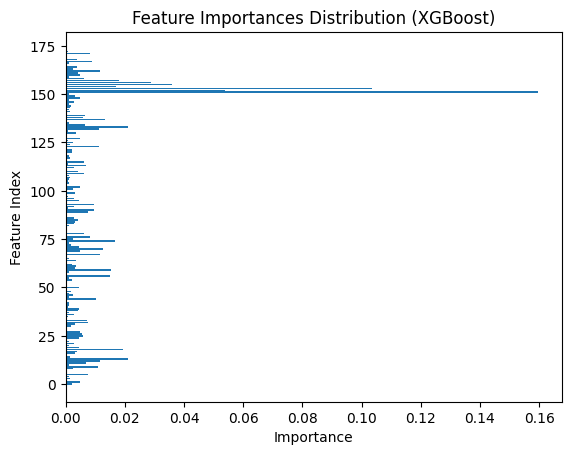

In [69]:
#https://xgboost.readthedocs.io/en/stable/get_started.html

import xgboost as xgb

# setup the model
model_tree = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    learning_rate=0.05,    
    max_depth=3,          
    n_estimators=200       
)

model_tree.fit(X_train, y_train)

# get the feature importances
feature_importances = model_tree.feature_importances_

# # draw the feature importances (1-151 queries, 152-158 categories, 159-173 app usages, 174 cluster label)
plt.barh(range(len(feature_importances)), feature_importances)
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.title('Feature Importances Distribution (XGBoost)')
plt.show()

### Evaluations

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost accuracy: {accuracy * 100:.2f}%")

In [38]:
# get the mapping of app labels to app names
app_label_to_name = dict(zip(le.transform(le.classes_), le.classes_))

# get the mapping of app labels to app categories
app_label_to_category = dict(zip(le.transform(le.classes_), app_categories))

In [57]:
# get the probabilities of each app
probs = model_tree.predict_proba(X_test)

# choose 5 random queries to display the results
random_indices = np.random.choice(len(X_test), 5, replace=False)

query_results = []

# present the top 3 app recommendations for each query and the corresponding categories
for idx in random_indices:
    query_text = df_filtered.iloc[idx]['Query']   # get the query text from the DataFrame
    
    top_3_labels = probs[idx].argsort()[-3:][::-1]
    
    # label to app name and category
    top_3_apps = [app_label_to_name[label] for label in top_3_labels]
    top_3_categories = [app_label_to_category[label] for label in top_3_labels]
    
    search_intent = cluster_test[idx]
    
    result = {
        "query_text": query_text,
        "search_intent": search_intent,
        "top_3_apps": top_3_apps,
        "top_3_categories": top_3_categories
    }
    
    query_results.append(result)

for result in query_results:
    print(f"Query: {result['query_text']}")
    print(f"Clustering Label: {result['search_intent']}")
    print(f"Top 3 APP recommendation: {result['top_3_apps']}\n")

    clean_categories = [category[0] for category in result['top_3_categories']]

    print(f"Top 3 APP category: {clean_categories}\n")

Query: doe chocolate covered expresso beans product energy
Clustering Label: [7]
Top 3 APP recommendation: ['chrome', 'messenger', 'myaccount']

Top 3 APP category: ['Communication', 'Communication', 'Video Players & Editors']

Query: pictures from debi hayes
Clustering Label: [6]
Top 3 APP recommendation: ['chrome', 'weatherforecast', 'myaccount']

Top 3 APP category: ['Communication', 'Communication', 'Video Players & Editors']

Query: bedtime sounds
Clustering Label: [4]
Top 3 APP recommendation: ['youtube', 'weatherforecast', 'chrome']

Top 3 APP category: ['Video Players & Editors', 'Communication', 'Communication']

Query: weather current location
Clustering Label: [6]
Top 3 APP recommendation: ['chrome', 'myaccount', 'yahoomail']

Top 3 APP category: ['Communication', 'Video Players & Editors', 'Communication']

Query: tylenol dose for babys
Clustering Label: [1]
Top 3 APP recommendation: ['chrome', 'instagram', 'messenger']

Top 3 APP category: ['Communication', 'Social', 'Comm

In [58]:
# find the actual app with query text
for result in query_results:
    actual_query = df_filtered.loc[df_filtered['Query'] == result['query_text'], 'Query']
    actual_app = df_filtered.loc[df_filtered['Query'] == result['query_text'], 'App']
    actual_category = df_filtered.loc[df_filtered['Query'] == result['query_text'], 'category']

    print(f"Query: {actual_query.values}, APP: {actual_app.values}, Category:{actual_category.values}")  


Query: ['doe chocolate covered expresso beans product energy'], APP: ['chrome'], Category:['Communication']
Query: ['pictures from debi hayes'], APP: ['yahoomail'], Category:['Communication']
Query: ['bedtime sounds'], APP: ['youtube'], Category:['Video Players & Editors']
Query: ['weather current location'], APP: ['chrome'], Category:['Communication']
Query: ['tylenol dose for babys' 'tylenol dose for babys'], APP: ['chrome' 'google'], Category:['Communication' 'Tools']


In [67]:
# calculate top-3 accuracy
def top_k_accuracy(y_true, y_prob, k=3):
    top_k_preds = np.argsort(y_prob, axis=1)[:, -k:]  
    correct = np.sum([1 if y_true[i] in top_k_preds[i] else 0 for i in range(len(y_true))])
    return correct / len(y_true)

# calculate MRR
def mean_reciprocal_rank(y_true, y_prob):
    ranks = []
    for i, true_app in enumerate(y_true):
        sorted_pred = np.argsort(y_prob[i])[::-1]  
        rank = np.where(sorted_pred == true_app)[0][0] + 1  
        ranks.append(1 / rank)
    return np.mean(ranks)

# calculate P@1
def precision_at_1(y_true, y_prob):
    top_1_preds = np.argmax(y_prob, axis=1)  
    return np.mean(top_1_preds == y_true)

y_prob = model_tree.predict_proba(X_test)

top_3_acc = top_k_accuracy(y_test, y_prob, k=3)
print(f"Top-3 Accuracy: {top_3_acc:.4f}")

mrr_score = mean_reciprocal_rank(y_test, y_prob)
print(f"MRR: {mrr_score:.4f}")

p_at_1 = precision_at_1(y_test, y_prob)
print(f"Precision at 1 (P@1): {p_at_1:.4f}")

Top-3 Accuracy: 0.9595
MRR: 0.9229
Precision at 1 (P@1): 0.8784
